Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model



100%|██████████| 11.0M/11.0M [00:00<00:00, 93.9MB/s]

Extracting files...


Process the data and split into training and validation sets. Use Tensorflows function to work.

In [ ]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, GridSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)


def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_model,
    objective="val_accuracy",
    max_trials=4,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifier"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results):
  toPlot = results.groupby("param_" + param)["mean_test_score"].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean Accuracy")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])




model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])

model1.summary()
showHyperPlot("base_filters", model1Results)
showHyperPlot("dense_units", model1Results)

Trial 4 Complete [00h 03m 28s]
val_accuracy: 0.8266666531562805

Best val_accuracy So Far: 0.9066666960716248
Total elapsed time: 00h 10m 15s
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6040 - loss: 1.2016 - val_accuracy: 0.6667 - val_loss: 0.6329
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6711 - loss: 0.6247 - val_accuracy: 0.6667 - val_loss: 0.6425
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6711 - loss: 0.6045 - val_accuracy: 0.6800 - val_loss: 0.5594
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7349 - loss: 0.5245 - val_accuracy: 0.8400 - val_loss: 0.4609
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8054 - loss: 0.4525 - val_accuracy: 0.8533 - val_loss: 0.4036


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,705,128 (37.02 MB)

 Trainable params: 3,235,042 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,470,086 (24.68 MB)

KeyError: 'param_base_filter'

Let's try creation a second model and see which one is more accurate. We're going to build a scikit learn shallow learning model.

{'max_depth': None, 'max_features': 4}
0.84
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        27
           1       0.86      0.90      0.88        48

    accuracy                           0.84        75
   macro avg       0.83      0.82      0.82        75
weighted avg       0.84      0.84      0.84        75



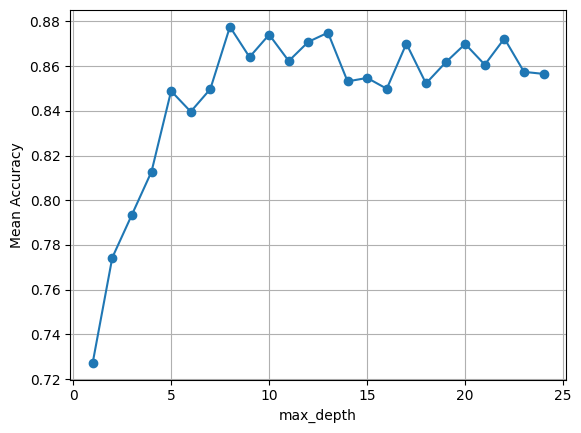

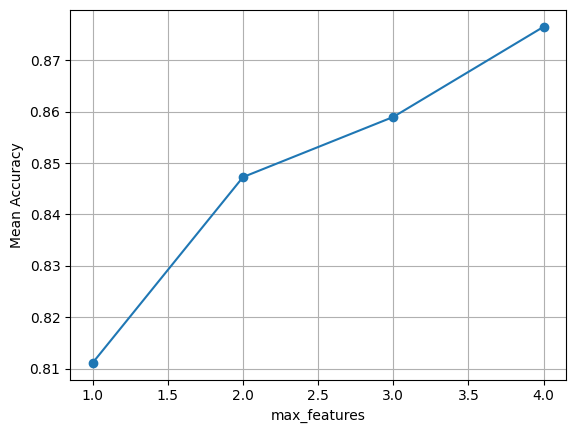

In [3]:
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report
# I have to flatten arrays because sklearn only allows 1D arrays
def flattenArrays(arr):
    return arr.reshape(len(arr), -1)

#Let's tune hyperparameters
#tune max_depth
param_grid = {
  #add params to test
  'max_depth': [None, *range(1, 25)],
  'max_features': [1, 2, 3, 4]
}

grid_search = GridSearchCV(tree.DecisionTreeClassifier(), param_grid=param_grid, scoring='accuracy')

grid_search.fit(flattenArrays(trainingImagesArray), flattenArrays(trainingClassifyArray))
print(grid_search.best_params_)

model2 = grid_search.best_estimator_
validationCheck = model2.predict(flattenArrays(validationImagesArray))
print(accuracy_score(validationCheck, validationClassifyArray))
print(classification_report(validationCheck, validationClassifyArray))

#create the plots.
showHyperPlot("max_depth", pd.DataFrame(grid_search.cv_results_))
showHyperPlot("max_features", pd.DataFrame(grid_search.cv_results_))

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

In [ ]:
#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)

# test model 1

# test model 2
testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
testCheck = model2.predict(flattenArrays(testImagesArray))
print(accuracy_score(testClassifyArray, testCheck))
print(classification_report(testClassifyArray, testCheck))





0.6410256410256411
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.64      0.78        78

    accuracy                           0.64        78
   macro avg       0.50      0.32      0.39        78
weighted avg       1.00      0.64      0.78        78



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
